# Assignment 11
**Author:** Lan Stare
**Date:** 5. 12. 2025

### (a)

In [9]:
import numpy as np

def explicit_Euler(f, t0, u0, tau, N):
    t = t0
    u = np.array(u0)   #we store it as an array so it also works when m > 1
    list_of_un = [u.copy()]     #storing u0 but the array version
    
    for n in range(N):   #we don't raise t because we want to use t0 when n = 1 (t_n-1 at nth step)
        u = u + tau * f(t, u)   #euler formula for un
        t += tau    #increasing the step
        list_of_un.append(u.copy())     #we need to copy it otherwise the value will change with u :) that's just how python works
        
    return list_of_un

### (b)

In [10]:
def modified_Euler(f, t0, u0, tau, N):      #we use the midpoint rule here
    t = t0
    u = np.array(u0)
    list_of_un = [u.copy()]     #same as in a)
    ts = []     #we wanna keep a list for t as well
    
    for n in range(1, N + 1):
        #midpoint
        u_half = u + 1/2 * tau * f(t0 + (n - 1)*tau, u)       #we're evaluating f at t_{n - 1} = t0 + (n - 1)*tau
        t_half = t0 + (n - 1/2) * tau       #formula for t_{n - 1/2}
                
        u = u + tau * f(t_half, u_half)     #usual full step incrementation
        t = t0 + n * tau        #calculating new t
        
        ts.append(t)    #remembering past ts
        list_of_un.append(u.copy())
        
    return list_of_un

### (c)

In [14]:
def lotka_volterra(t, uv):
    x, y = uv
    lam1, lam2 = 1.0, 0.5       #defining parameters
    xe, ye   = 15.0, 10.0

    dx = lam1 * x * (1 - y / ye)        #this is just defined by wanted formula
    dy = lam2 * y * (x / xe - 1)

    return np.array([dx, dy])

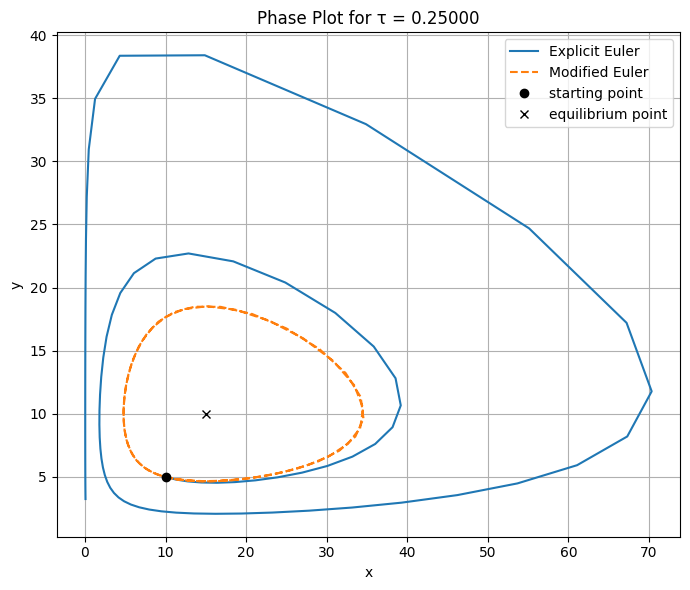

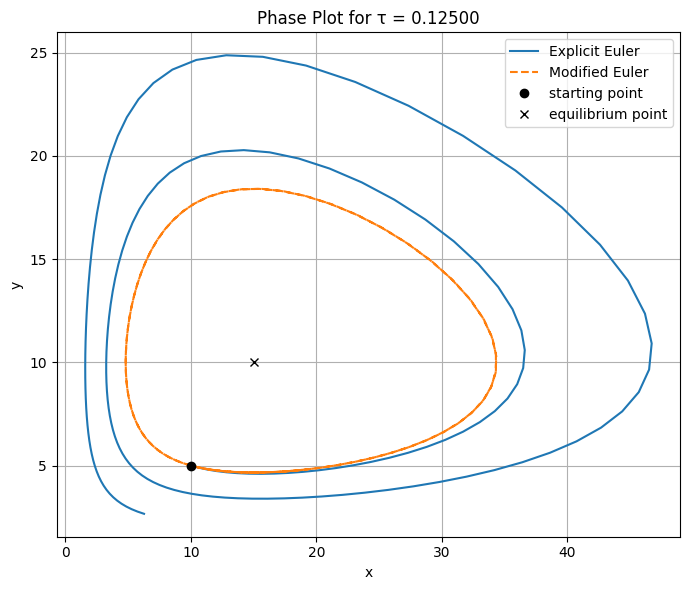

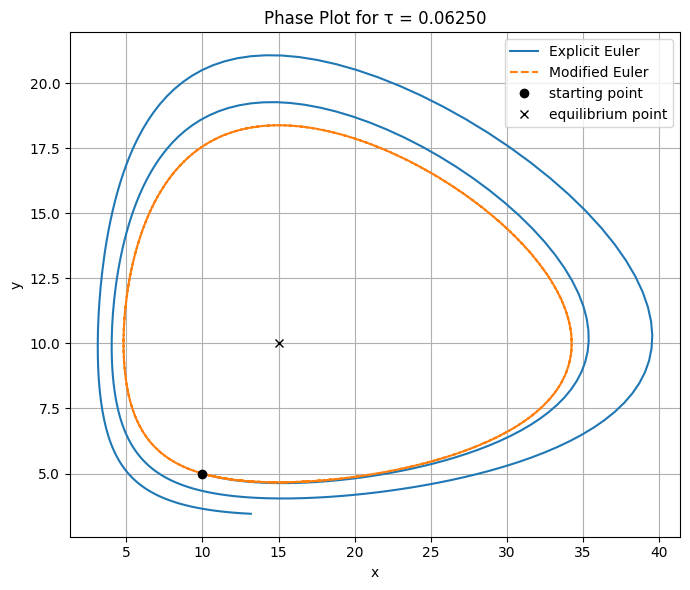

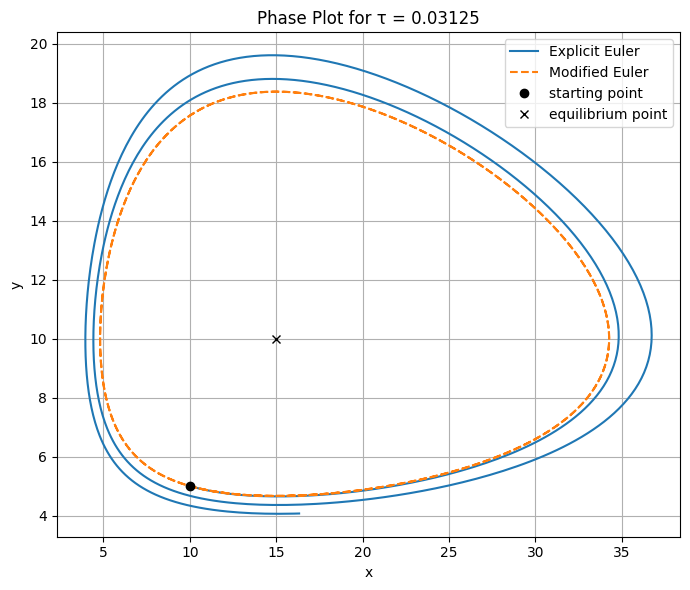

In [20]:
#Now let's plot:
import matplotlib.pyplot as plt

t0, T = 0, 20
u0 = np.array([10.0, 5.0])      #starting state of (x0, y0)
base = (T - t0) * 0.0125          #base = 20 * 0.0125 = 0.25    
taus = [base * 2**(-i) for i in range(4)]   #definine tau values

for tau in taus:
    N = int((T - t0) / tau)     #numebr of steps for current tau

    #trajectory with explicit euler
    eu = explicit_Euler(lotka_volterra, t0, u0, tau, N)
    eu = np.array(eu)       #converting into an array (or rather a matrix)
    x_eu, y_eu = eu[:,0], eu[:,1]

    #trajectory with modified euler
    me = modified_Euler(lotka_volterra, t0, u0, tau, N)
    me = np.array(me)
    x_me, y_me = me[:,0], me[:,1]

    #plotting phase plane (x, y)
    plt.figure(figsize=(7,6))
    plt.plot(x_eu, y_eu, label="Explicit Euler")
    plt.plot(x_me, y_me, label="Modified Euler", linestyle='--')    #so that it differs from explicit euler

    plt.plot(u0[0], u0[1], "ko", label="starting point")   #starting point
    plt.plot(15, 10, "kx", label="equilibrium point")     #equilibrium point

    plt.title(f"Phase Plot for τ = {tau:.5f}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.legend()      
    plt.tight_layout()
    plt.show()

ANSWER:

From all the plots we can clearly see that modified euler approximates the periodic closed orbit better because explicit euler does not preserve the closed orbit structure.